# Telecom Customer Churn Analysis

## 04: Multivariate Analysis and Customer Churn

### Objective

This notebook investigates how multiple customer characteristics, service usage patterns, and account factors interact in relation to customer churn.

The analysis focuses on:

- Examining how tenure and contract type interact in relation to churn
- Investigating how internet type, service subscriptions, and billing characteristics relate to churn when considered together
- Exploring how customer profile characteristics and tenure interact with churn
- Examining the relationship between offers, customer tenure, and churn
- Identifying combined patterns that may provide additional insight beyond individual bivariate relationships

This builds on the bivariate analysis by examining multiple variables together to better understand how customer characteristics and behaviors interact in relation to churn.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Load cleaned dataset from first notebook
churn_df = pd.read_parquet('../data/processed/telecom_customer_churn_clean.parquet')

In [3]:
# Set visualization settings
sns.set_theme(style='white', 
              context='notebook', 
              palette='deep')

plt.rcParams['figure.figsize'] = (5, 3)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 16
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelpad'] = 6
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

### Tenure, Contract, and Churn
- How does churn rate vary with tenure across different contract types?
- Are the tenure patterns of churn similar across contracts?

In [27]:
tenure_bins = list(range(1, 74, 12))
tenure_labels = [f'{tenure}-{tenure+11}' for tenure in tenure_bins[:-1]]

churn_df['Tenure Group'] = pd.cut(
    churn_df['Tenure in Months'],
    bins=tenure_bins,
    labels=tenure_labels,
    right=False
)

churn_rate_by_tenure_contract = (
    churn_df.groupby(['Tenure Group', 'Contract'])['Customer Status']
     .value_counts()[:, :, 'Churned'] /
    churn_df.groupby(['Tenure Group', 'Contract'])['Customer Status']
     .count()
    * 100
).unstack()

churn_rate_by_tenure_contract

Contract,Month-to-Month,One Year,Two Year
Tenure Group,,,
1-12,53.528489,8.904110,0.000000
13-24,40.524781,7.441860,0.000000
25-36,36.489607,7.462687,1.526718
37-48,37.588652,12.589928,1.980198
49-60,31.100478,13.496933,3.703704
61-72,27.586207,11.987382,3.090728


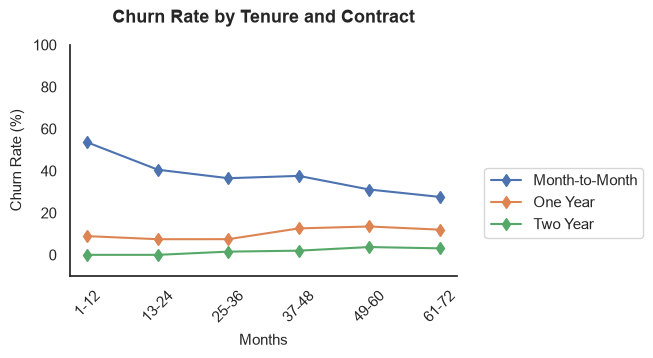

In [57]:
fig, ax = plt.subplots()

churn_rate_by_tenure_contract.plot.line(
ax=ax,
marker='d'
)

ax.set_title('Churn Rate by Tenure and Contract')
ax.set_xlabel('Months')
ax.set_ylabel('Churn Rate (%)')
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 0.5));
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(-10, 100);


- Customers on month-to-month contracts consistently have higher churn rates than customers on one-year or two-year contracts across all tenure groups.
- Month-to-month customers have their highest churn rate during the first 12 months and generally declines as tenure increases.
- In comparison, churn remains much lower and relatively stable among customers on one-year and two-year contracts across tenure groups.

### Internet Services, Billing, and Churn
- Does the relationship between monthly charges and churn vary across internet types?

In [58]:
charge_bins = list(range(-10, 131, 20))
charge_labels = [f'{charge}-{charge+19}' for charge in charge_bins[:-1]]

churn_df['Charge Group'] = pd.cut(
    churn_df['Monthly Charge'],
    bins=charge_bins,
    labels=charge_labels,
    right=False
)

churn_rate_by_charge_internet = (
    churn_df.groupby(['Charge Group', 'Internet Type'])['Customer Status']
     .value_counts()[:, :, 'Churned'] /
    churn_df.groupby(['Charge Group', 'Internet Type'])['Customer Status']
     .count()
    * 100
).unstack()

churn_rate_by_charge_internet

Internet Type,Cable,DSL,Fiber Optic,None
Charge Group,,,,
-10-9,33.333333,17.142857,36.170213,11.538462
10-29,41.666667,36.363636,NaN,7.333333
30-49,30.693069,30.516432,NaN,NaN
50-69,17.941176,15.660920,60.194175,NaN
70-89,21.761658,7.671958,49.838969,NaN
90-109,60.000000,3.448276,35.689293,NaN
110-129,100.000000,NaN,13.084112,NaN


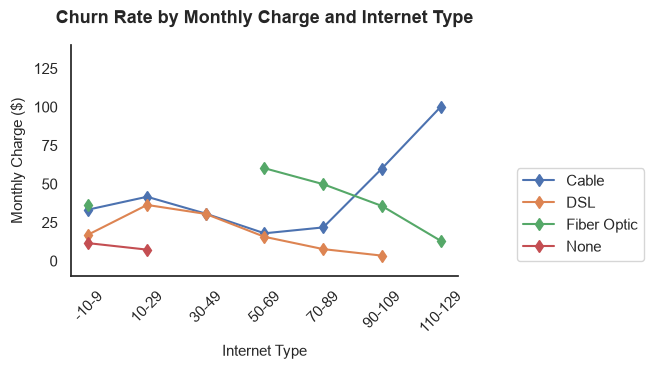

In [60]:
fig, ax = plt.subplots()

churn_rate_by_charge_internet.plot.line(
ax=ax,
marker='d'
)

ax.set_title('Churn Rate by Monthly Charge and Internet Type')
ax.set_xlabel('Internet Type')
ax.set_ylabel('Monthly Charge ($)')
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 0.5));
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(-10, 140);


### Additional Services, Contract, and Churn
- Does the relationship between additional service subscriptions and churn differ across contract types?
- Are certain combinations of services and contracts associated with different churn rates?

### Customer Profile, Tenure, and Churn
- Does the relationship between age and churn vary with customer tenure?
- Do household characteristics and tenure show different churn patterns?

### Offers, Tenure, and Churn
- How does churn vary across offers at different tenure levels?
- Are differences in churn across offers partly associated with the tenure profiles of customers receiving those offers?

### Summary